In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


We plot all of stds in one place, for a final comparison.

In [2]:
data_interval =  np.linspace(0, +1200, 100)

In [ ]:
# Refer to "std_calculate.ipynb" for this.
std_results = np.genfromtxt("std_results.csv",delimiter=",")
x = std_results[:,0]
y = std_results[:,1]

In [ ]:
# Refer to "btc_std_calc_fixed_tick.ipynb", "btc_std_calc_2_states.ipynb","btc_std_calc_4_states.ipynb","btc_std_calc_8_states.ipynb","btc_std_calc_16_states_.ipynb","btc_std_calc_32_states_\ .ipynb"

par0 = 0.47048692523512375
par2 = 5.128311251164073
par4 = 11.656266484769137
par8 = 7.911472515735503
par16 = 7.678095906401425
par32 = 7.2000715888858275

In [5]:
colors = np.array(["#e31a1c","#1f78b4", "#33a02c", "#6a3d9a", "#ff7f00",  "#b15928",
                               "#a6cee3", "#b2df8a", "#fb9a99", "#fdbf6f", "#cab2d6", "#ffff99"])


Regression coefficients (fitted on n >= 200):
Model: y = 12.787256 + 7.123004 * sqrt(x)
Intercept: 12.787256
Slope (C): 7.123004


/var/folders/0w/63qd3s9d3ylfvdcjxhz7y1c40000gn/T/ipykernel_36763/3962145572.py:37: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(x_smooth, regression_line, '-', label='Regression', color="orange", linewidth=2,linestyle="dashed")


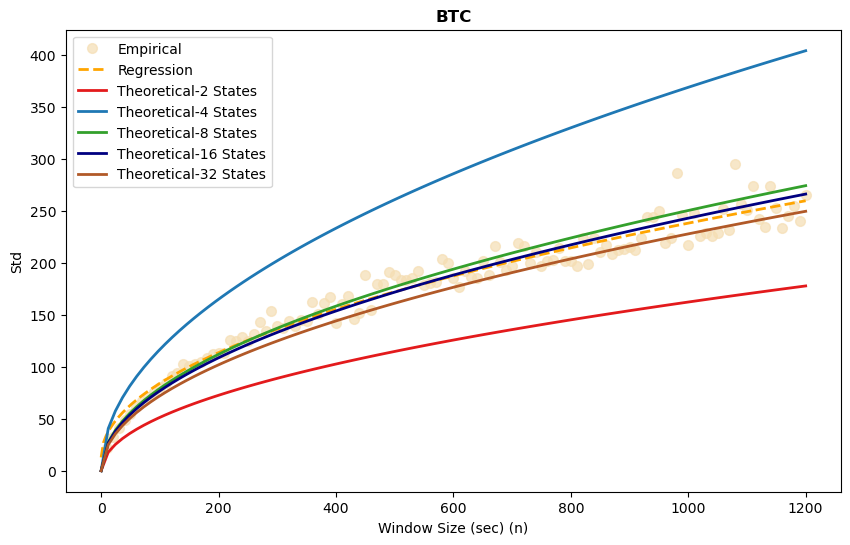

In [26]:
# Add regression line: y = C * sqrt(x), starting from n=200
plt.figure(figsize=(10,6))

"""# Filter data for n >= 200
mask = x >= 200
x_filtered = x[mask]
y_filtered = y[mask]"""

# Fit model: std = C * sqrt(window_size) using only n >= 200
# Transform x to sqrt(x) and fit linear regression
x_sqrt_filtered = np.sqrt(x)
# Fit y = C * sqrt(x) (linear regression in transformed space)
coeffs = np.polyfit(x_sqrt_filtered, y, 1) 

# Print coefficients
print(f"\nRegression coefficients (fitted on n >= 200):")
print(f"Model: y = {coeffs[1]:.6f} + {coeffs[0]:.6f} * sqrt(x)")
print(f"Intercept: {coeffs[1]:.6f}")
print(f"Slope (C): {coeffs[0]:.6f}")

plt.plot(
    x, 
    y, 
    'o',
    color="wheat",
    label='Empirical',
    alpha=0.7,
    markersize=7
)



# Create smooth line for plotting, starting from n=200
x_smooth = np.linspace(0, x.max(), 300)
x_smooth_sqrt = np.sqrt(x_smooth)
regression_line = np.polyval(coeffs, x_smooth_sqrt)
plt.plot(x_smooth, regression_line, '-', label='Regression', color="orange", linewidth=2,linestyle="dashed")

plt.plot(data_interval,np.sqrt(data_interval)*par2,color = colors[0],label = "Theoretical-2 States",linewidth = 2 )
plt.plot(data_interval,np.sqrt(data_interval)*par4,color= colors[1],label = "Theoretical-4 States",linewidth = 2 )
plt.plot(data_interval,np.sqrt(data_interval)*par8,color= colors[2],label = "Theoretical-8 States",linewidth = 2 )
plt.plot(data_interval,np.sqrt(data_interval)*par16,color= "navy",label = "Theoretical-16 States",linewidth = 2 )
plt.plot(data_interval,np.sqrt(data_interval)*par32,color= colors[5],label = "Theoretical-32 States",linewidth = 2 )






plt.title("BTC", fontweight='bold')
plt.xlabel('Window Size (sec) (n)')
plt.ylabel('Std')
plt.legend()

plt.show()

We further emphasize the difference that the adjusted tick sizes' make, visually.


Regression coefficients (fitted on n >= 200):
Model: y = 12.787256 + 7.123004 * sqrt(x)
Intercept: 12.787256
Slope (C): 7.123004


/var/folders/0w/63qd3s9d3ylfvdcjxhz7y1c40000gn/T/ipykernel_36763/1803944105.py:37: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(x_smooth, regression_line, '-', label='Regression', color="orange", linewidth=2,linestyle="dashed")


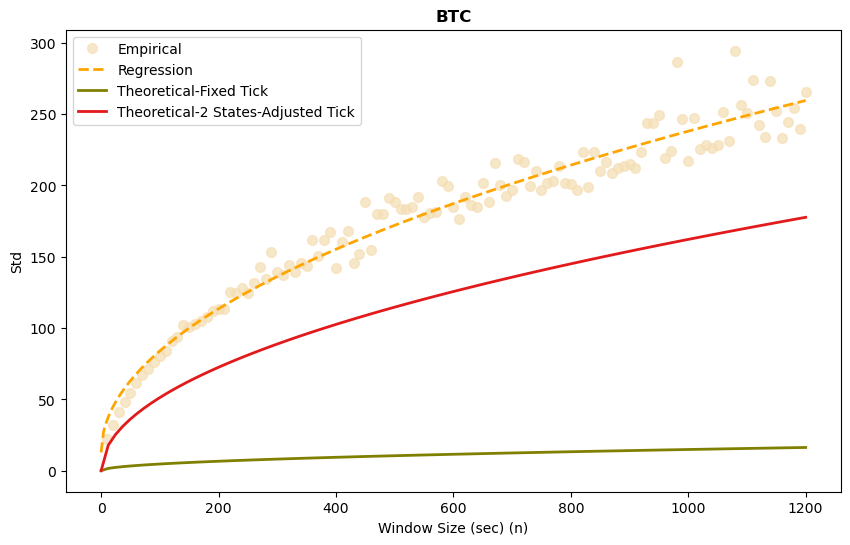

In [ ]:
# Add regression line: y = C * sqrt(x), starting from n=200
plt.figure(figsize=(10,6))

"""# Filter data for n >= 200
mask = x >= 200
x_filtered = x[mask]
y_filtered = y[mask]"""

# Fit model: std = C * sqrt(window_size) using only n >= 200
# Transform x to sqrt(x) and fit linear regression
x_sqrt_filtered = np.sqrt(x)
# Fit y = C * sqrt(x) (linear regression in transformed space)
coeffs = np.polyfit(x_sqrt_filtered, y, 1) 

# Print coefficients
print(f"\nRegression coefficients (fitted on n >= 200):")
print(f"Model: y = {coeffs[1]:.6f} + {coeffs[0]:.6f} * sqrt(x)")
print(f"Intercept: {coeffs[1]:.6f}")
print(f"Slope (C): {coeffs[0]:.6f}")

plt.plot(
    x, 
    y, 
    'o',
    color="wheat",
    label='Empirical',
    alpha=0.7,
    markersize=7
)



# Create smooth line for plotting, starting from n=200
x_smooth = np.linspace(0, x.max(), 300)
x_smooth_sqrt = np.sqrt(x_smooth)
regression_line = np.polyval(coeffs, x_smooth_sqrt)
plt.plot(x_smooth, regression_line, '-', label='Regression', color="orange", linewidth=2,linestyle="dashed")

plt.plot(data_interval,np.sqrt(data_interval)*par0,color = "olive",label = "Theoretical-Fixed Tick",linewidth = 2 )
plt.plot(data_interval,np.sqrt(data_interval)*par2,color = colors[0],label = "Theoretical-2 States-Adjusted Tick",linewidth = 2 )



plt.title("BTC", fontweight='bold')
plt.xlabel('Window Size (sec) (n)')
plt.ylabel('Std')
plt.legend()

plt.show()